### Load and Clean Data
Remove cancellations (negative quantities) and rows without Customer IDs.

In [2]:
import pandas as pd
import datetime as dt

# Load the data
df = pd.read_excel('../data/online_retail_II.xlsx')

# Data Cleaning - Remove rows with missing Customer ID
df = df.dropna(subset=['Customer ID'])

# Remove cancelled transactions (Invoice starting with 'C')
df = df[~df['Invoice'].astype(str).str.contains('C')]

# Create a TotalPrice column (Quantity * Price)
df['TotalPrice'] = df['Quantity'] * df['Price']

print(f"Data Loaded: {df.shape[0]} rows")
df.head()

Data Loaded: 407695 rows


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Calculate RFM Metrics
Transforming individual transactions into a customer-level summary.

In [3]:
# Set a reference date for analysis (usually 1 day after the last transaction in data)
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by Customer ID to calculate R, F, and M
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                       # Monetary
})

# Rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


### Scoring the Customers (1 to 5)
Ranking customers. A score of 1 is the best, 4 is the worst (or vice versa depending on logic). Let's use quantiles (splitting data into 4 equal parts).

Recency: Lower is better (purchased recently).

Frequency: Higher is better (purchases often).

Monetary: Higher is better (spends more).

In [4]:
# Create labels (4 is best for F and M, 1 is best for R)
r_labels = range(4, 0, -1) # 4, 3, 2, 1 (High recency = Bad score)
f_labels = range(1, 5)     # 1, 2, 3, 4 (High frequency = Good score)
m_labels = range(1, 5)     # 1, 2, 3, 4 (High monetary = Good score)

# Create 'R_Score', 'F_Score', 'M_Score' using qcut
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

# Create a combined RFM Score string (e.g., "411")
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Create a total Score (sum of numbers)
rfm['RFM_Score_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score_Total
Customer ID,,,,,,,,
12346.0,165,11,372.86,1,4,2,142,7
12347.0,3,2,1323.32,4,2,3,423,9
12348.0,74,1,222.16,2,1,1,211,4
12349.0,43,3,2671.14,3,3,4,334,10
12351.0,11,1,300.93,4,1,1,411,6


### Define Customer Segments
Note: This is the business value part. We interpret the scores.

In [5]:
def segment_customer(df):
    if df['RFM_Score_Total'] >= 9:
        return 'Champions'
    elif (df['RFM_Score_Total'] >= 6) and (df['RFM_Score_Total'] < 9):
        return 'Potential Loyalists'
    elif (df['RFM_Score_Total'] >= 5) and (df['RFM_Score_Total'] < 6):
        return 'Need Attention'
    else:
        return 'At Risk/Lost'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

# View the distribution of segments
print(rfm['Customer_Segment'].value_counts())

Customer_Segment
Champions              1673
Potential Loyalists    1384
At Risk/Lost            790
Need Attention          467
Name: count, dtype: int64


### Visualizing the Customer Segments
Let's use Matplotlib and Seaborn to create 6 specific charts that tell the story of the customer base

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_style('whitegrid')

#### Chart 1: Distribution of Customer Segments
This shows "How many customers are in each group?"

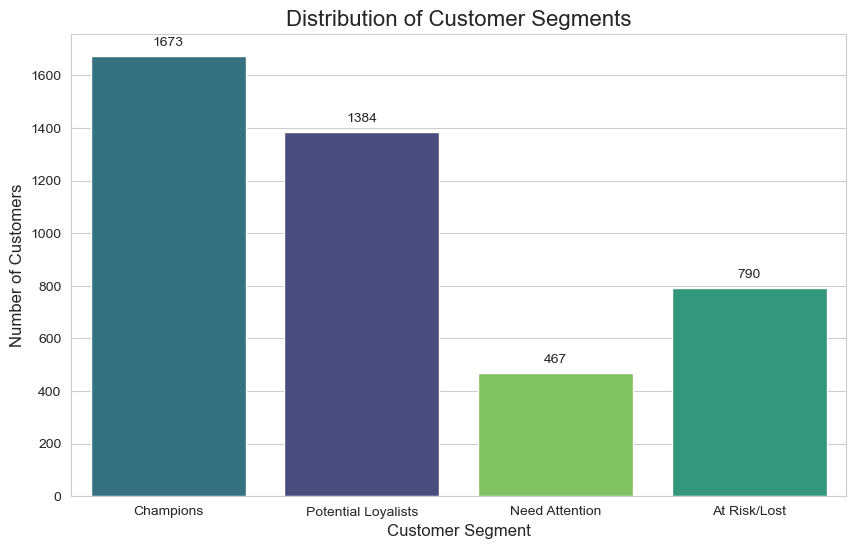

In [7]:
plt.figure(figsize=(10, 6))
segment_order = ['Champions', 'Potential Loyalists', 'Need Attention', 'At Risk/Lost']

# Create the bar chart
ax = sns.countplot(
    x='Customer_Segment', 
    data=rfm, 
    order=segment_order, 
    palette='viridis', 
    hue='Customer_Segment', # Avoiding FutureWarnings
    legend=False 
)

plt.title('Distribution of Customer Segments', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

"You can see that our 'Champions' make up X% of the user base. However, a large portion is 'At Risk', indicating a need for a re-engagement campaign."

#### Chart 2: Recency vs Frequency (The Activity View)
This shows that Champions buy often and recently, while At Risk are far right (high recency)

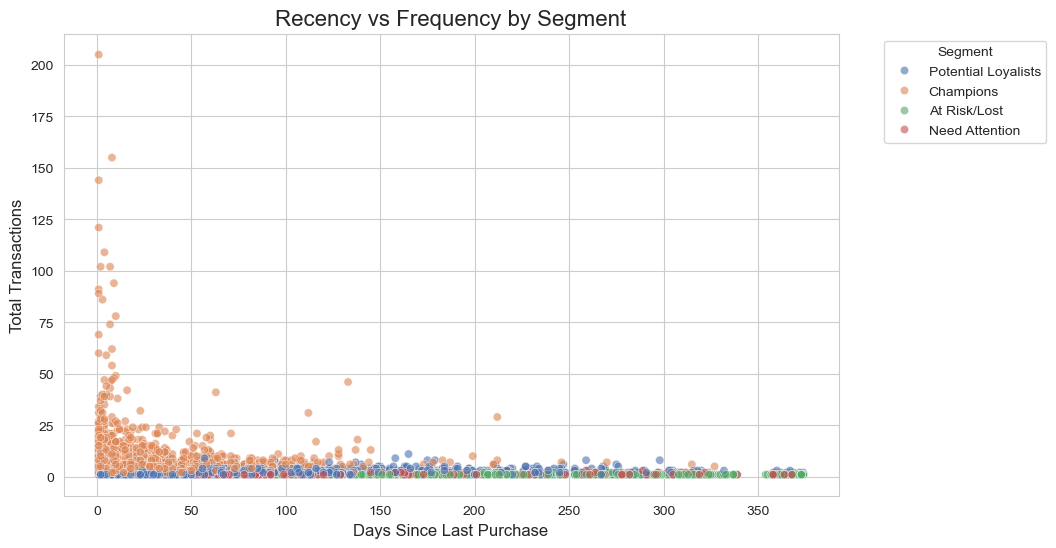

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Recency', 
    y='Frequency', 
    hue='Customer_Segment', 
    data=rfm, 
    palette='deep',
    alpha=0.6 # Make points slightly transparent to see overlap
)

plt.title('Recency vs Frequency by Segment', fontsize=16)
plt.xlabel('Days Since Last Purchase', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

"This visualizes the clear separation between segments. 'Champions' (blue dots) are clustered in the top-left (Recent & Frequent), while 'At Risk' users drift to the right."

#### Chart 3: Average Metrics by Segment (The "Business Value" View)
This explains "Why" they are Champions (High Monetary, Low Recency)

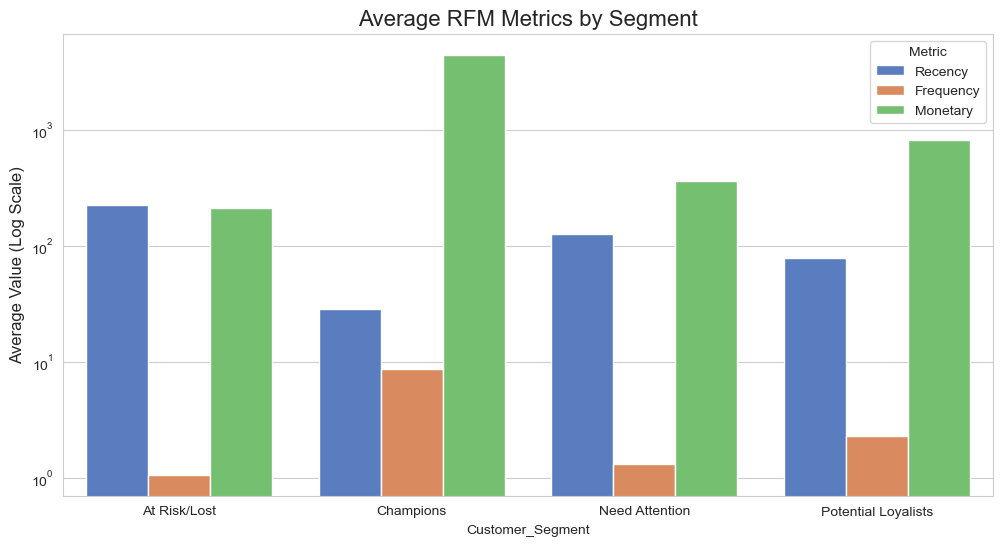

In [9]:
# We calculate the average values first
rfm_agg = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()

# Reshape data for plotting
rfm_melted = pd.melt(rfm_agg, id_vars=['Customer_Segment'], var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Customer_Segment', y='Value', hue='Metric', data=rfm_melted, palette='muted')

plt.title('Average RFM Metrics by Segment', fontsize=16)
plt.yscale('log') # Use logarithmic scale because 'Monetary' is much larger than 'Frequency'
plt.ylabel('Average Value (Log Scale)', fontsize=12)
plt.legend(title='Metric')
plt.show()

"This proves the value of the 'Champions' segment, their Average Monetary Value is exponentially higher than other groups."

### Chart 4: The Geographic Map (Revenue by Country)
 This visualization shows global reach. Since in the dataset we have the Country column, we can aggregate revenue by country.

In [19]:
import plotly.express as px

# 1. Prepare the data: Group by Country
country_data = df.groupby('Country').agg({
    'TotalPrice': 'sum',
    'Customer ID': 'nunique'
}).reset_index()

# Rename columns for the map
country_data.columns = ['Country', 'Total Revenue', 'Number of Customers']

# 2. Create the Choropleth Map
fig = px.choropleth(
    country_data, 
    locations='Country', 
    locationmode='country names', # This tells Plotly to match names like 'France', 'United Kingdom'
    color='Total Revenue',
    hover_name='Country',
    hover_data=['Number of Customers'],
    color_continuous_scale=px.colors.sequential.Plasma,
    title='Global Revenue Distribution by Country'
)

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

C:\Users\User\AppData\Local\Temp\ipykernel_31748\323635977.py:13: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



"Visualized global sales performance across 30+ countries using Plotly interactive maps, highlighting key markets outside the UK."

#### Chart 5: The "Business Trend" (Monthly Revenue)
As StakeHolders always ask: "Are we growing?"
So, for this we will use line chart to show the trends.

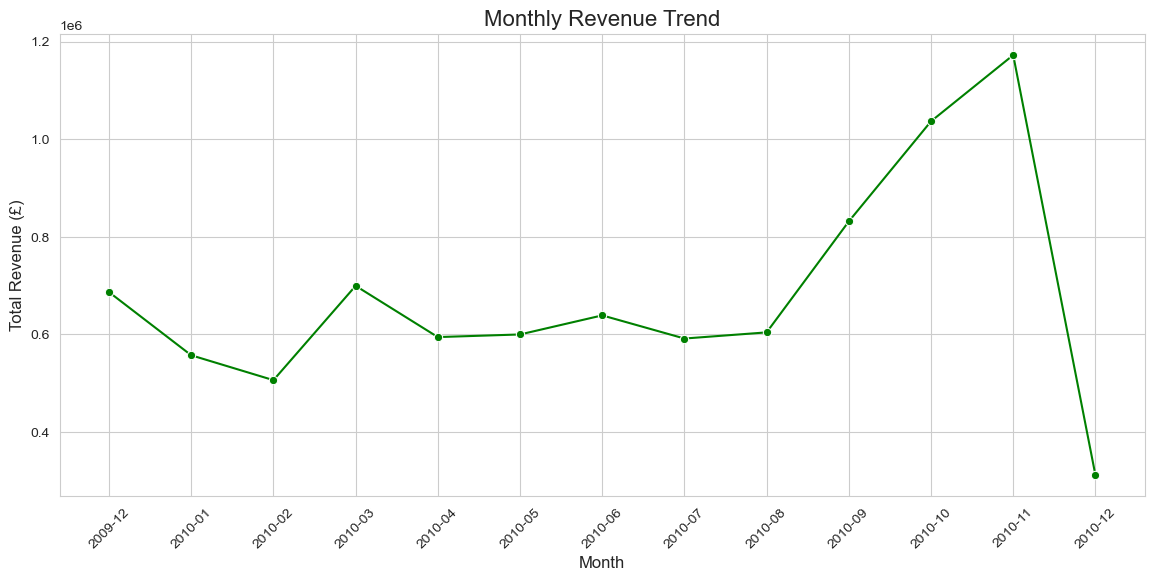

In [11]:
# 1. Prepare the data: Extract Year-Month
df['Month_Year'] = df['InvoiceDate'].dt.to_period('M')

# Group by month
monthly_sales = df.groupby('Month_Year')['TotalPrice'].sum().reset_index()

# Convert Month_Year back to string/timestamp for plotting
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)

# 2. Plot the Trend
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, x='Month_Year', y='TotalPrice', marker='o', color='green')

plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### Chart 6: The "Treemap" (Segment Breakdown)
I am choosing Treemap as it is often better than a Pie Chart for showing how different segments contribute to the whole. It looks very professional.

In [18]:
# Calculate total revenue per segment
segment_revenue = rfm.groupby('Customer_Segment')['Monetary'].sum().reset_index()

# Create Treemap
fig_tree = px.treemap(
    segment_revenue, 
    path=['Customer_Segment'], 
    values='Monetary',
    title='Revenue Contribution by Customer Segment',
    color='Monetary',
    color_continuous_scale='RdBu'
)

fig_tree.show()

### Advanced Trend Analysis (Moving Averages)
A simple line chart is often too "spiky." We will calculate a 30-Day Moving Average to show the underlying trend direction.

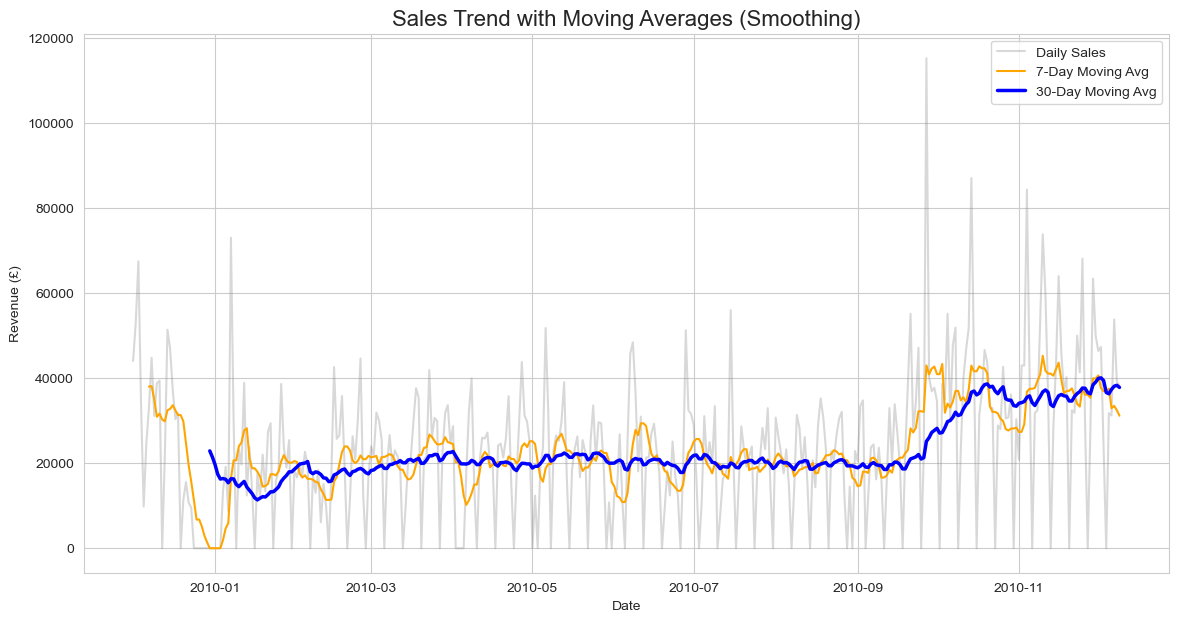

In [13]:
# 1. Aggregate daily sales
daily_sales = df.groupby('InvoiceDate')['TotalPrice'].sum().reset_index()
daily_sales = daily_sales.set_index('InvoiceDate')

# 2. Resample to ensure every day is present (fill gaps with 0)
daily_sales = daily_sales.resample('D').sum()

# 3. Calculate Moving Averages (7-day and 30-day)
daily_sales['7_Day_MA'] = daily_sales['TotalPrice'].rolling(window=7).mean()
daily_sales['30_Day_MA'] = daily_sales['TotalPrice'].rolling(window=30).mean()

# 4. Plotting
plt.figure(figsize=(14, 7))

# Plot raw data (faint)
plt.plot(daily_sales.index, daily_sales['TotalPrice'], alpha=0.3, label='Daily Sales', color='gray')

# Plot Moving Averages (bold)
plt.plot(daily_sales.index, daily_sales['7_Day_MA'], label='7-Day Moving Avg', color='orange', linewidth=1.5)
plt.plot(daily_sales.index, daily_sales['30_Day_MA'], label='30-Day Moving Avg', color='blue', linewidth=2.5)

plt.title('Sales Trend with Moving Averages (Smoothing)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Revenue (£)')
plt.legend()
plt.grid(True)
plt.show()

Insight: "The blue line (30-day trend) shows us the real direction of growth, ignoring daily fluctuations."

### Machine Learning - K-Means Clustring
The Workflow:

Pre-processing: K-Means hates outliers and different scales (e.g., Money is 10,000, Frequency is 5). We must Log Transform and Scale the data.

Elbow Method: Finding the optimal number of clusters (K).

Model Fitting: Then we will Run the algorithm.

##### Preprocessing

In [14]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Prepare the data (Log transformation to handle skewness)
# We add +1 to avoid log(0) error
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log(x + 1))

# 2. Standardize the data (Mean=0, Std=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert back to dataframe for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm_log.columns)

print("Data Normalized and Scaled.")
rfm_scaled_df.head()

Data Normalized and Scaled.


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.965369,1.613486,-0.535112
12347.0,-1.900370,-0.394241,0.447389
12348.0,0.354254,-0.981463,-0.935944
12349.0,-0.055950,0.022400,0.992701
12351.0,-1.055337,-0.981463,-0.701107


##### The Elbow Method
Now we need to ask the machine: "Should we have 3 groups? 4? 5?" The Elbow Method tells us.

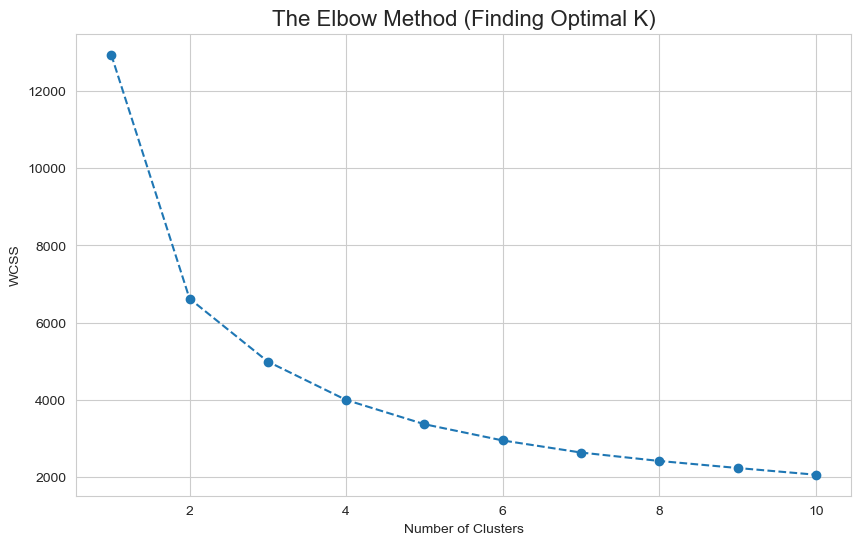

In [20]:
from sklearn.cluster import KMeans

wcss = [] # Within-Cluster Sum of Square

# Test cluster numbers 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (Finding Optimal K)', fontsize=16)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Action: Look at the chart. The "Elbow" is usually where the curve bends the most (likely at K=3 or K=4). Let's assume K=3 for this example.

##### Training the Model and Visualizing
Let's build the final model with 3 clusters.

In [17]:
# 1. Fit the model with K=3 (Change to 4 if the elbow suggests it)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# 2. Assign the labels back to the original data
rfm['Cluster_Labels'] = kmeans.labels_

# 3. Analyze the averages of each cluster to name them
cluster_summary = rfm.groupby('Cluster_Labels').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster_Labels': 'count' # To see size of each cluster
}).rename(columns={'Cluster_Labels': 'Count'})

print(cluster_summary)

# 4. 3D Visualization of Clusters
import plotly.express as px

fig = px.scatter_3d(
    rfm, 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color=rfm['Cluster_Labels'].astype(str), # Convert to string so it treats as category
    opacity=0.7,
    title='3D Customer Segments (K-Means Clustering)',
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.show()

                   Recency  Frequency     Monetary  Count
Cluster_Labels                                           
0               164.291860   1.302326   322.654182   1720
1                54.313559   3.384746  1282.668747   1770
2                18.225728  13.330097  7289.701939    824


Look at the cluster_summary table output. You will see 3 distinct groups (0, 1, 2).

1) Cluster 0 (Example): Low Recency, High Frequency, High Monetary -> These are your "Whales" (VIPs).

2) Cluster 1 (Example): High Recency, Low Frequency -> These are "Lost Customers".

3) Cluster 2 (Example): Average everything -> "Casual Buyers".